### Import dependencies
- Load core libraries for modeling, evaluation, visualization, and interpretation.
- `XGBClassifier` is the main classification model used.
- `shap` is used to explain predictions.
- `product` from `itertools` is used for manual hyperparameter grid creation.

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score
)
import shap
import joblib
import os
from itertools import product

### Define file paths
- Set the path to the normalized panel dataset.
- Define output paths for:
  - Model files
  - SHAP values
  - Feature importances
  - Evaluation metrics

In [203]:
DATA_PATH = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
IMPORTANCE_DIR = "../data/feature_importance/per_country"
MODEL_DIR = "../models/per_country"
SHAP_DIR = "../data/shap_values/per_country"
METRICS_DIR = "../data/model_performance/per_country"

### Create output directories
- Create folders if they do not already exist for:
  - Models (`MODEL_DIR`)
  - SHAP values (`SHAP_DIR`)
  - Feature importances (`IMPORTANCE_DIR`)
  - Evaluation metrics (`METRICS_DIR`)


In [204]:
os.makedirs(IMPORTANCE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

### Initial setup
- Set:
  - `DROP_COLS`: columns excluded from training (`date`, `Country`)
  - `RANDOM_STATE`: for reproducibility
  - `TARGETS`: available classification targets
  - `TRAIN_START`, `TRAIN_END`, `VAL_END`, `TEST_END`: default date cutoffs (not used here but declared globally)


In [205]:
DROP_COLS = ['date', 'Country']
RANDOM_STATE = 42
TARGETS = ["RECESS", "RECESS_OVER", "RECESS_PERIOD"]
TRAIN_START, TRAIN_END = "1995-01-01", "2009-12-31"
VAL_END, TEST_END = "2018-12-31", "2024-05-31"

### Load panel dataset and prepare date format
- Load the VIF-normalized panel dataset from Excel.
- Convert the `date` column to datetime format for time-based slicing.

In [206]:
df = pd.read_excel(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

# Results
all_results = []

### Data cutoff for this modeling run
- Set custom split points for training, validation, and testing:
  - Train: up to end of 2014
  - Validation: 2015–2019
  - Test: 2020–2024


In [207]:
train_start = "1995-01-01"
train_end   = "2014-12-31"
val_end     = "2019-12-31"
test_end    = "2025-05-31"

### Target country and target indicator
- Select the country to model and target.
- Filter the dataset for the selected country only.

In [287]:
country = "CHI"
target = "RECESS"
df_country = df[df["Country"] == country].copy()

### Sanity check
- Ensure there is sufficient variation in the target variable (must include both 0s and 1s).
- If not, exit early to avoid model training on unbalanced targets.

In [288]:
if df_country[target].nunique() < 2:
    print(f"[SKIP] Not enough variation for {target} in {country}")
    exit()

print(f"[INFO] Proceeding with {country} — target: {target}")

[INFO] Proceeding with CHI — target: RECESS


### Data splits
### Define features and create time-based splits
- Drop irrelevant columns to create the feature matrix `X`.
- Use the selected `target` column as `y`.
- Create masks to define train, validation, and test sets based on `date`.


In [289]:
# Drop non-feature columns
X = df_country.drop(columns=DROP_COLS + TARGETS)
y = df_country[target]

# Time-based masks
train_mask = (df_country['date'] >= train_start) & (df_country['date'] <= train_end)
val_mask   = (df_country['date'] > train_end) & (df_country['date'] <= val_end)
test_mask  = (df_country['date'] > val_end) & (df_country['date'] <= test_end)

### Apply time-based masks to split the dataset
- Use the masks to create:
  - `X_train`, `y_train`
  - `X_val`, `y_val`
  - `X_test`, `y_test`

In [290]:
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

### Fallback for missing validation positives
- If the validation set has no positive examples:
  - Merge train and validation into a single training set.
  - Temporarily use the test set as validation (used only for threshold tuning).

In [291]:
if y_val.sum() == 0:
    print(f"[WARNING] No positives in validation for {country} - {target}. Merging train + val.")
    X_train = pd.concat([X_train, X_val])
    y_train = pd.concat([y_train, y_val])

    X_val = X_test.copy()   # Use test as validation for threshold tuning (still keep test metrics separate)
    y_val = y_test.copy()

### Show split sizes and date ranges
- Print the number of samples in each split.
- Display the date ranges for training, validation, and test sets.

In [292]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df_country[train_mask]['date'].min().date()} to {df_country[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df_country[val_mask]['date'].min().date()} to {df_country[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df_country[test_mask]['date'].min().date()} to {df_country[test_mask]['date'].max().date()}")


Train: 240 samples
Validation: 60 samples
Test: 53 samples
Train Date Range: 1995-01-01 to 2014-12-01
Validation Date Range: 2015-01-01 to 2019-12-01
Test Date Range: 2020-01-01 to 2024-05-01


In [293]:
print("Test Positive Count:", (y_test == 1).sum())
print("Validation Positive Count:", (y_val == 1).sum())

Test Positive Count: 23
Validation Positive Count: 60


### Compute scale_pos_weight
- Calculate the ratio of negative to positive samples in the training set.
- Used to mitigate class imbalance when training XGBoost.

In [294]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"[INFO] scale_pos_weight = {scale_pos_weight:.2f}")

[INFO] scale_pos_weight = 0.55


### Define hyperparameter grid
- Define a small grid with a single combination of parameters for this run.
- Includes `scale_pos_weight` as a tunable parameter.

In [295]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [3],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [1.0],
    'scale_pos_weight': [scale_pos_weight]
}

### Generate all hyperparameter combinations
- Use `itertools.product` to enumerate all combinations in `param_grid`.

In [296]:
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

### Initialize tracking variables
- Store:
  - `best_model`: the best trained classifier
  - `best_f1`: highest validation F1 score
  - `best_thresh`: threshold that yielded the best F1
  - `best_params`: dictionary of best hyperparameters

In [297]:
best_model = None
best_f1 = 0
best_thresh = 0.5
best_params = {}

### Building the model
- Loop over all parameter combinations:
  - Train model on `X_train`, `y_train`
  - Predict probabilities on `X_val`
  - Tune threshold between 0.10 and 0.89 to find best F1
  - Track the best model and settings

In [298]:
for combo in combinations:
    model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=RANDOM_STATE, **combo)
    model.fit(X_train, y_train)
    y_val_prob = model.predict_proba(X_val)[:, 1]

    for t in np.arange(0.1, 0.9, 0.01):
        y_val_pred = (y_val_prob > t).astype(int)
        f1 = f1_score(y_val, y_val_pred)
        print(f"[DEBUG] Combo: {combo} | Threshold: {t:.2f} | F1: {f1:.3f}")  # ← Add this

    if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
            best_model = model
            best_params = combo

[DEBUG] Combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(0.5483870967741935)} | Threshold: 0.10 | F1: 1.000
[DEBUG] Combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(0.5483870967741935)} | Threshold: 0.11 | F1: 1.000
[DEBUG] Combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(0.5483870967741935)} | Threshold: 0.12 | F1: 1.000
[DEBUG] Combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(0.5483870967741935)} | Threshold: 0.13 | F1: 1.000
[DEBUG] Combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(0.5483870967741935)} | Threshold: 0.14 | F1: 1.000


C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:22:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Generate predictions on test set
- Use the best model and best threshold to generate final binary predictions on `X_test`.


In [299]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]
print("y_test")
y_test_pred = (y_test_prob > best_thresh).astype(int)

y_test


### Model performance evaluation
- Compute performance metrics on test set:
  - AUC, F1, Precision, Recall, Accuracy


In [300]:
auc = roc_auc_score(y_test, y_test_prob)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)

### Print model results
- Print out all evaluation metrics along with the selected threshold and parameters.


In [301]:
print(f"[RESULTS] AUC: {auc:.3f}, F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, Accuracy: {accuracy:.3f}")
print(f"\n[RESULTS] Best threshold: {best_thresh} | Params: {best_params}")

[RESULTS] AUC: 0.625, F1: 0.548, Precision: 0.436, Recall: 0.739, Accuracy: 0.472
[RESULTS] Best threshold: 0.8899999999999996 | Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(0.5483870967741935)}


### Log final results
- Append results to `all_results` for tracking country-target performance.
- Includes model metrics, country, target, threshold, and scale_pos_weight.

In [302]:
all_results.append({
    "Country": country,
    "Target": target,
    "AUC": auc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh,
    "Cost_Sensitive_Rate": scale_pos_weight
})

In [308]:
results_df = pd.DataFrame(all_results)
results_df

,Country,Target,AUC,F1,Precision,Recall,Accuracy,Threshold,Cost_Sensitive_Rate
0,MEX,RECESS,0.245833,0.000000,0.000000,0.00000,0.509434,0.89,2.287671
1,GER,RECESS,0.416667,0.064516,0.038462,0.20000,0.452830,0.89,0.818182
2,JAP,RECESS,0.818182,0.439024,0.281250,1.00000,0.566038,0.89,1.424242
3,CHI,RECESS,0.624638,0.548387,0.435897,0.73913,0.471698,0.89,0.548387


### SHAP
- Initialize a SHAP `Explainer` using the trained XGBoost model.
- Calculate SHAP values for each training instance to understand which features contributed most to predictions.

In [303]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)
shap_df = pd.DataFrame(shap_values.values, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

### Generate SHAP bar plot
- Create a bar plot showing the top 20 most important features.
- Use mean absolute SHAP values to highlight feature impact.
- Save the figure as a high-resolution image with the country and target in the filename.

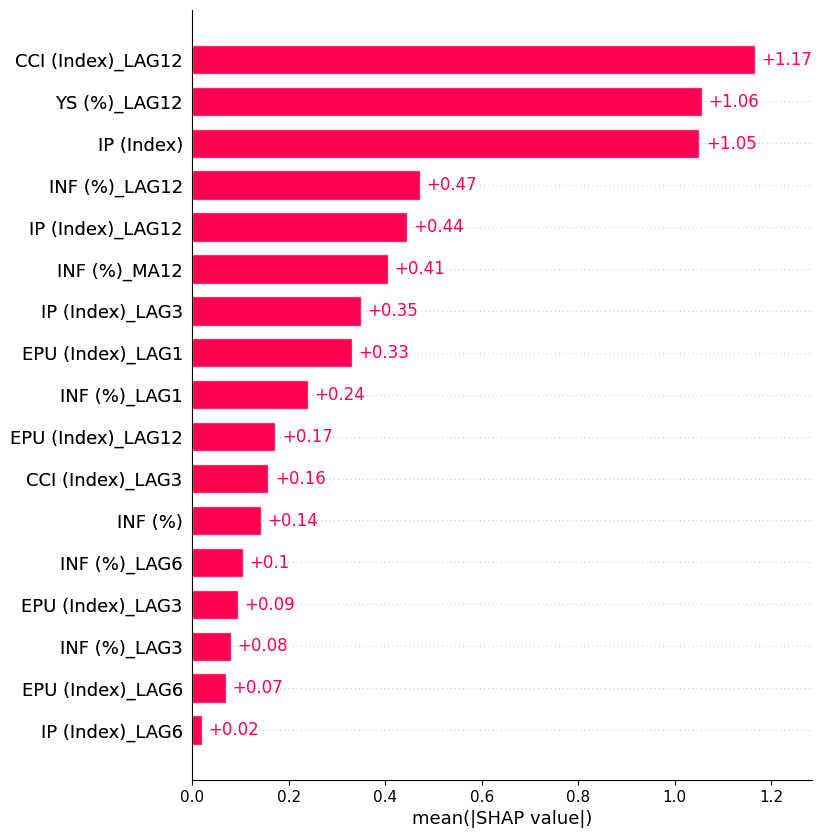

In [304]:
shap.plots.bar(shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_train.values,
    feature_names=X_train.columns
), max_display=20, show=True)

In [305]:
plt.close()

### Generate SHAP beeswarm plot
- Create a beeswarm plot to show the distribution of SHAP values per feature.
- Visualizes both feature importance and directionality (positive or negative impact).

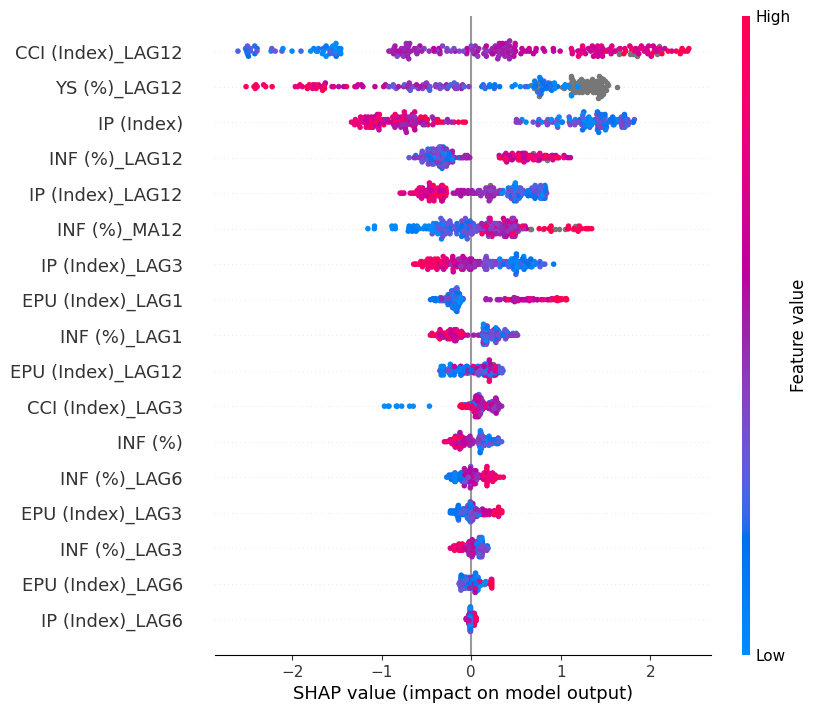

In [306]:
shap.plots.beeswarm(shap_values, max_display=20, show=True)

In [307]:
plt.close()